# qGAN experiment tutorial

This notebook has two workflows:

1. Execute one generated experiment and visualize its output.
2. Execute a battery of generated experiments.

`qml_torch` is the Qiskit Machine Learning adapter. `runtime_packed` is the primitive-backed packed Runtime adapter, and `manual_estimator` is a scaffolded entry point for non-QML implementations.

## 1. Setup

Run this notebook from inside the repository or from `qgan/notebooks`. The cell below makes `qgan/src` importable without installing the package.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = None

for candidate in (cwd, *cwd.parents):
    if (candidate / "src" / "qgan_v2").is_dir() and (candidate / "configs").is_dir():
        qgan_dir = candidate
        break
    if (candidate / "qgan" / "src" / "qgan_v2").is_dir():
        qgan_dir = candidate / "qgan"
        break

if qgan_dir is None:
    raise RuntimeError("Could not find qgan project directory from current working directory.")

repo_root = qgan_dir.parent
src_path = qgan_dir / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("qgan_dir:", qgan_dir)
print("repo_root:", repo_root)

qgan_dir: /home/benat/Qiskit-IBM/qgan
repo_root: /home/benat/Qiskit-IBM


In [2]:
from qgan_v2.config.battery import create_battery_configs
from qgan_v2.config.loader import load_run_config
from qgan_v2.implementations.registry import IMPLEMENTATIONS
from qgan_v2.main import run_battery, run_train
from qgan_v2.storage.paths import get_run_path, get_training_data_filename
from qgan_v2.training.data import load_training_data_file
from qgan_v2.visualization import get_visual_config, run_visualization

sorted(IMPLEMENTATIONS)

['manual_estimator', 'qml_torch', 'runtime_packed']

## 2. IBM Runtime Credentials

Run this once before experiments that refresh IBM backend metadata or execute on IBM Runtime. The token is read with `getpass`, saved as the default Qiskit Runtime account, and verified immediately.


In [3]:
from getpass import getpass
from qiskit_ibm_runtime import QiskitRuntimeService

save_account = False

if save_account:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token="",
        instance=None,
        set_as_default=True,
        overwrite=True,
        verify=True,
    )

service = QiskitRuntimeService()
print("IBM Runtime account saved and verified.")
print("Available backends:", len(service.backends()))


IBM Runtime account saved and verified.
Available backends: 1


## 3. Single Experiment

This section expands the test battery, selects one generated config by run id, executes it, then visualizes the checkpoint. The default target is a small angle-encoding smoke test.

In [4]:
battery_path = qgan_dir / "configs" / "batteries" / "train_cpu.yaml"
config_files = create_battery_configs(battery_path, overwrite=True)

Creating config files for qml_torch_noiseless:
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed1/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed2/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed2/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-SPSA-aerCPU-rand

In [5]:
target_run_id = "base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0"

configs_by_run_id = {}

for path in config_files:
    cfg = load_run_config(path)
    configs_by_run_id[cfg["run"]["id"]] = Path(path)

config_path = configs_by_run_id[target_run_id]
config = load_run_config(config_path)
run_path = get_run_path(config)
training_data_file = get_training_data_filename(config)

print("selected config:", config_path)
print("selected run id:", config["run"]["id"])
print("run_path:", run_path)
print("training_data_file:", training_data_file)
print("dataset:", config["dataset"])
print("training:", config["training"])

selected config: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml
selected run id: base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0
run_path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0
training_data_file: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/training_data.pth
dataset: {'id': 'specific_distribution', 'reset': False, 'type': 'quantum', 'source': 'specific_distribution', 'parameters': {}}
training: {'max_iterations': 1000, 'gen_iterations': 1, 'disc_iterations': 1, 'init_scale': 0.1, 'learning_rate': 0.005, 'print_every': 100, 'checkpoint_every': 100}


### Execute Single Experiment

This runs only the selected config. Increase `training.max_iterations` in the YAML when the smoke test works.

In [6]:
state = run_train(str(config_path), reset_data=False)

config = load_run_config(config_path)
training_data_file = get_training_data_filename(config)

/home/benat/Qiskit-IBM/qgan/src/qgan_v2/training/data.py:216: UserWarning: Training data config differs from current config:
- backend.real.channel: previous='ibm_quantum_platform', current=None
- backend.real.confirm_execution: previous=True, current=None
- backend.real.confirm_runtime_execution: previous=None, current=False
- backend.real.info_storage: previous=None, current='shared'
- backend.save_backend_file: previous=None, current=False
- encoding.random_circuit: previous=None, current=1
- run.data_path: previous='qgan_v4/data/train', current='qgan/data/train'
- training.checkpoint_every: previous=None, current=100
  warn_config_changes(training_state.config, config)


              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 
   Best eval: 0.030029362583253144 
   Total time: 230.682599067688


### Inspect Checkpoint

In [7]:
if training_data_file.exists():
    params = load_training_data_file(training_data_file)
    print("current_epoch:", params.current_epoch)
    print("metric keys:", list(vars(params.metrics).keys()))
    print("eval history:", params.metrics.eval)
else:
    print("No checkpoint yet. Run the single experiment cell first.")


current_epoch: 1000
metric keys: ['gloss', 'dloss', 'eval', 'times']
eval history: {0: 4.11203584023785, 1: 3.806058201667086, 2: 3.6610432614803172, 3: 3.595462261325321, 4: 3.5433569715152475, 5: 3.517320039389814, 6: 3.495424654233102, 7: 3.473762716947082, 8: 3.4552735128156007, 9: 3.4384826899929886, 10: 3.422929689317937, 11: 3.409338987245779, 12: 3.394954888695987, 13: 3.385409842830265, 14: 3.3775810866332057, 15: 3.3711892418365763, 16: 3.365551847550602, 17: 3.36564484832852, 18: 3.370753900301115, 19: 3.3807463203419292, 20: 3.3976519463306767, 21: 3.424260584013001, 22: 3.4666447775679456, 23: 3.5384596470242484, 24: 3.669647415631392, 25: 4.159493476942613, 26: 3.7030780874110163, 27: 3.4944893126386365, 28: 3.3695285517021407, 29: 3.2828114612468875, 30: 3.2136828653420872, 31: 3.1581809722838536, 32: 3.1087862630741045, 33: 3.06550605793903, 34: 3.026441609208306, 35: 2.9897590607799347, 36: 2.9579302917114614, 37: 2.929631621611231, 38: 2.909649709801461, 39: 2.8935566

### Visualize Single Experiment

Visualization only reads config files and checkpoints. It does not start training.

Run path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0
Circuits: 4 (generator, discriminator, randomizer, real circuits)
Hardware layout visualization is only available for runtime_packed.


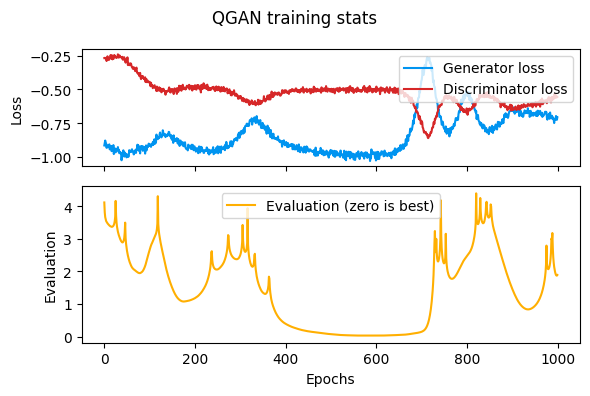

Training complete: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/training_data.pth 
Best evaluation: 0.030029362583253144 in epoch 569 
Improvement: 4.082006477654597


In [8]:
visual_config = get_visual_config({
    "draw_circuits": False,
    "draw_hardware_layout": True,
    "draw_probs": False,
    "draw_images": True,
    "draw_results": True,
})

run = run_visualization(config_path, visual_config)

### Optional Circuit Drawings

Circuit drawings can be large. Enable this only when you want the decomposed real circuits plus generator and discriminator circuit diagrams.

In [9]:
draw_circuits = False

if draw_circuits:
    run = run_visualization(
        config_path,
        {
            "draw_circuits": True,
            "draw_probs": True,
            "draw_images": True,
            "draw_results": True,
        },
    )

## 3. Battery Experiments

This section creates all configs from a battery file and executes the full battery. The default battery is `configs/batteries/test.yaml`, which is intentionally small. Use `configs/batteries/train.yaml` only when you want the larger training sweep.

In [10]:
battery_path = qgan_dir / "configs" / "batteries" / "train_cpu.yaml"
battery_config_files = create_battery_configs(battery_path, overwrite=True)

print("battery:", battery_path)
print("configs:", len(battery_config_files))

for path in battery_config_files:
    cfg = load_run_config(path)
    checkpoint = get_training_data_filename(cfg)
    print(cfg["run"]["id"], "checkpoint_exists=", checkpoint.exists())

Creating config files for qml_torch_noiseless:
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed0/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed1/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed2/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed2/config.yaml
Configuration file rewritten. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-SPSA-aerCPU-rand

In [ ]:
battery_path = qgan_dir / "configs" / "batteries" / "train_cpu.yaml"

battery_states = run_battery(battery_path, reset_data=False, reset_rb=False, stop_on_error=False, overwrite=False)
print("completed runs:", len(battery_states))

Creating config files for qml_torch_noiseless:
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed0/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed1/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed2/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed2/config.yaml
Configuration file already exists. Path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_

/home/benat/Qiskit-IBM/qgan/src/qgan_v2/training/data.py:216: UserWarning: Training data config differs from current config:
- backend.real.channel: previous='ibm_quantum_platform', current=None
- backend.real.confirm_execution: previous=True, current=None
- backend.real.confirm_runtime_execution: previous=None, current=False
- backend.real.info_storage: previous=None, current='shared'
- backend.save_backend_file: previous=None, current=False
- encoding.random_circuit: previous=None, current=1
- run.data_path: previous='qgan_v4/data/train', current='qgan/data/train'
- training.checkpoint_every: previous=None, current=100
  warn_config_changes(training_state.config, config)


              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 
   Best eval: 0.030029362583253144 
   Total time: 230.682599067688

Running: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed0/config.yaml
              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Training complete: 
   Data path: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0.1-seed0 
   Best eval: 0.010651926471313883 
   Total time: 235.62977027893066

Running: /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed1/config.yaml
              Epoch |     Generator cost | Discriminator cost |               Eval |          Best eval |               Time |
Tra

In [ ]:
battery_states

### Inspect Battery Results

In [ ]:
battery_results = []

for path in battery_config_files:
    cfg = load_run_config(path)
    checkpoint = get_training_data_filename(cfg)
    battery_results.append({
        "run_id": cfg["run"]["id"],
        "config": path,
        "checkpoint": checkpoint,
        "checkpoint_exists": checkpoint.exists(),
    })

for result in battery_results:
    print(result["run_id"], "done=" + str(result["checkpoint_exists"]))

## 4. Implementation Adapters

Changing `implementation.name` selects a different adapter. The generic training loop stays the same.

- `qml_torch`: working qgan_v2-owned Qiskit Machine Learning + Torch implementation.
- `runtime_packed`: primitive-backed packed Runtime implementation.
- `manual_estimator`: target for Qiskit primitives/gradients without `qiskit-machine-learning`.

`manual_estimator` intentionally raises `NotImplementedError` until its internals are implemented.

In [ ]:
for path in sorted((qgan_dir / "data" / "test").rglob("config.yaml")):
    cfg = load_run_config(path)
    print(path.relative_to(qgan_dir))
    print("  implementation:", cfg["implementation"]["name"])
    print("  preset:", cfg["experiment"]["implementation"])
    print("  gradient:", cfg["experiment"]["gradient_method"])
    print()

## 5. Thesis Results Analysis

This section loads completed experiment checkpoints and creates matched-comparison figures. Use `analysis_filters` to keep all non-compared variables fixed before interpreting a plot.

In [ ]:
import matplotlib.pyplot as plt

from qgan_v2.analysis import (
    filter_results,
    load_results,
    plot_convergence_comparison,
    plot_final_metric,
    plot_quality_vs_time,
    plot_runtime,
    print_group_summary,
    representative_runs,
    results_table,
    unique_values,
)

train_results = load_results(qgan_dir / "data" / "train")
test_results = load_results(qgan_dir / "data" / "test")

print("train runs:", len(train_results))
print("test runs:", len(test_results))
print("train presets:", unique_values(train_results, "preset"))
print("train implementations:", unique_values(train_results, "implementation"))
print("train execution types:", unique_values(train_results, "execution_type"))
print("train gradients:", unique_values(train_results, "gradient_method"))
print("train qubits:", unique_values(train_results, "n_qubits"))
print("train randomness:", unique_values(train_results, "randomness"))

### Comparable Groups

A group fixes the experimental configuration and varies only `run.seed`. Groups with at least two or three runs are the strongest candidates for thesis figures.

In [ ]:
print_group_summary(train_results, min_runs=2)

### Main Matched Comparison

Edit these filters to choose the thesis comparison. The example compares gradient methods while keeping preset, implementation, execution type, qubits, randomness, and simulator device fixed.

In [ ]:
analysis_results = train_results

analysis_filters = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "randomness": 0,
    "simulator_device": "CPU",
}

compare_by = "gradient_method"
selected = filter_results(analysis_results, **analysis_filters)

print("selected runs:", len(selected))
print("comparison values:", unique_values(selected, compare_by))
print("seeds:", unique_values(selected, "seed"))

### Evaluation Convergence

The primary convergence figure uses evaluation score, with individual seed curves plus a median line and interquartile range.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_convergence_comparison(
    analysis_results,
    compare_by=compare_by,
    filters=analysis_filters,
    metric="eval",
    x_axis="epoch",
    center="median",
    spread="iqr",
    ax=ax,
)
ax.set_title("Evaluation convergence across seeds")
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_convergence_comparison(
    analysis_results,
    compare_by=compare_by,
    filters=analysis_filters,
    metric="eval",
    x_axis="elapsed",
    center="median",
    spread="iqr",
    ax=ax,
)
ax.set_title("Evaluation convergence against elapsed time")
fig.tight_layout()

### Diagnostic Loss Curves

Generator and discriminator losses are diagnostic. Use them to explain instability, not as the main convergence result.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_convergence_comparison(
    analysis_results,
    compare_by=compare_by,
    filters=analysis_filters,
    metric="gloss",
    x_axis="epoch",
    center="median",
    spread="iqr",
    ax=axes[0],
)
axes[0].set_title("Generator loss")

plot_convergence_comparison(
    analysis_results,
    compare_by=compare_by,
    filters=analysis_filters,
    metric="dloss",
    x_axis="epoch",
    center="median",
    spread="iqr",
    ax=axes[1],
)
axes[1].set_title("Discriminator loss")

fig.tight_layout()

### Final Quality And Runtime

These plots show individual seed points and the distribution for each compared configuration.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_final_metric(
    analysis_results,
    compare_by=compare_by,
    metric_name="best_eval",
    filters=analysis_filters,
    ax=axes[0],
)
axes[0].set_title("Best evaluation")

plot_final_metric(
    analysis_results,
    compare_by=compare_by,
    metric_name="last_window_median_eval",
    filters=analysis_filters,
    ax=axes[1],
)
axes[1].set_title("Last-window median evaluation")

plot_runtime(
    analysis_results,
    compare_by=compare_by,
    metric_name="time_per_epoch",
    filters=analysis_filters,
    log_scale=True,
    ax=axes[2],
)
axes[2].set_title("Runtime per epoch")

fig.tight_layout()

### Quality Versus Runtime

Use this as a tradeoff plot. Keep filters narrow when making claims about a specific factor.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_quality_vs_time(
    analysis_results,
    color_by="gradient_method",
    marker_by="execution_type",
    quality_metric="best_eval",
    time_metric="total_time",
    filters=analysis_filters,
    ax=ax,
)
ax.set_title("Quality versus runtime")
fig.tight_layout()

### Representative Outputs

Use best, median, and worst seeds for visual examples. The visualizer reads the selected run's `config.yaml` and checkpoint.

In [ ]:
representatives = representative_runs(selected, metric_name="best_eval")

for name, result in representatives.items():
    print(name, result.run_id, result.path / "config.yaml")

In [ ]:
representative_name = "median"

if representatives:
    representative_config = representatives[representative_name].path / "config.yaml"
    run_visualization(
        representative_config,
        get_visual_config({
            "draw_circuits": False,
            "draw_hardware_layout": False,
            "draw_probs": True,
            "draw_images": True,
            "draw_results": True,
        }),
    )

### Result Table

The table rows are plain dictionaries so the notebook works without pandas. If pandas is installed, the second cell renders a sortable dataframe.

In [ ]:
summary_rows = results_table(selected)

for row in summary_rows[:10]:
    print({
        "run_id": row["run_id"],
        "seed": row["seed"],
        "best_eval": row["best_eval"],
        "final_eval": row["final_eval"],
        "completed_epochs": row["completed_epochs"],
        "time_per_epoch": row["time_per_epoch"],
    })

In [ ]:
try:
    import pandas as pd

    display(pd.DataFrame(summary_rows).sort_values([compare_by, "seed"]))
except ImportError:
    print("pandas is not installed; use summary_rows directly.")